### Naive Bayes Classifier Demonstration

This demonstration will cover the basic steps of using a Naive Bayes classifier:
1.  **Generate Sample Data**: Create a synthetic dataset for classification.
2.  **Split Data**: Divide the dataset into training and testing sets.
3.  **Train Model**: Initialize and train a Gaussian Naive Bayes model.
4.  **Make Predictions**: Use the trained model to predict on the test set.
5.  **Evaluate Model**: Assess the performance of the classifier using common metrics.

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

#### 1. Generate Sample Data

We'll create a simple synthetic dataset with two features and two classes using `make_classification` from `sklearn.datasets`.

In [ ]:
from sklearn.datasets import make_classification

# Generate a synthetic dataset
X, y = make_classification(n_samples=200, n_features=2, n_informative=2,
                           n_redundant=0, n_clusters_per_class=1, random_state=42)

# Convert to a pandas DataFrame for easier viewing
df = pd.DataFrame(X, columns=['feature_1', 'feature_2'])
df['target'] = y

print("First 5 rows of the dataset:")
display(df.tail())

print("\nDistribution of target classes:")
print(df['target'].value_counts())

First 5 rows of the dataset:


,feature_1,feature_2,target
195,-2.325239,-0.919512,0
196,-0.741314,1.970952,0
197,-0.581615,1.196672,0
198,0.871664,1.690409,1
199,0.937104,3.525581,0



Distribution of target classes:
target
1    100
0    100
Name: count, dtype: int64


#### 2. Visualize the Data

Let's visualize the generated data to understand the separation between classes.

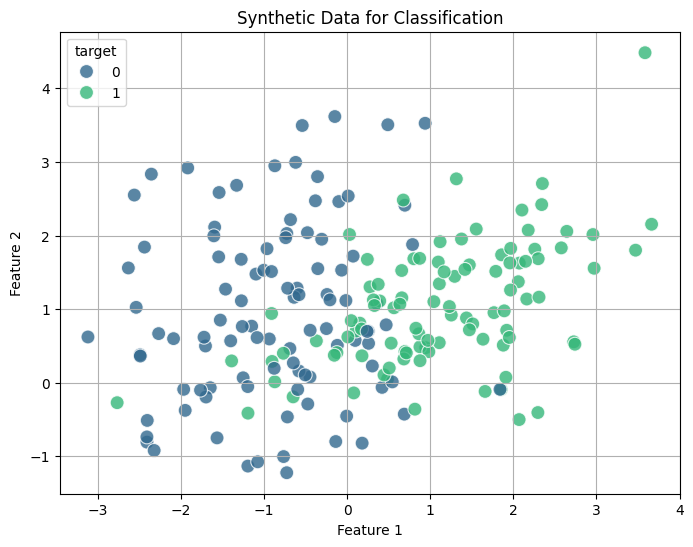

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='feature_1', y='feature_2', hue='target', data=df, palette='viridis', s=100, alpha=0.8)
plt.title('Synthetic Data for Classification')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True)
plt.show()

#### 3. Split Data into Training and Testing Sets

We'll split the data to train the model on one part and evaluate its performance on unseen data.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Training set size: {len(X_train)} samples")
print(f"Testing set size: {len(X_test)} samples")

Training set size: 140 samples
Testing set size: 60 samples


#### 4. Train the Gaussian Naive Bayes Model

Gaussian Naive Bayes is suitable for continuous data and assumes that the features are normally distributed within each class.

In [ ]:
# Initialize the Gaussian Naive Bayes classifier
gnb = GaussianNB()

# Train the model using the training data
gnb.fit(X_train, y_train)

print("Model training complete.")

Model training complete.


#### 5. Make Predictions

Now, let's use the trained model to predict the target variable for the test set.

In [ ]:
# Make predictions on the test set
y_pred = gnb.predict(X_test)

print("First 10 actual labels from test set:", y_test[:10])
print("First 10 predicted labels from test set:", y_pred[:10])

First 10 actual labels from test set: [1 0 1 1 1 1 0 1 0 1]
First 10 predicted labels from test set: [1 0 1 1 1 1 0 0 0 1]


#### 6. Evaluate Model Performance

We'll evaluate the model using common classification metrics like accuracy, precision, recall, F1-score, and a confusion matrix.

Accuracy: 0.8667
Precision: 0.8667
Recall: 0.8667
F1-Score: 0.8667

Confusion Matrix:


,Predicted Negative,Predicted Positive
Actual Negative,26,4
Actual Positive,4,26


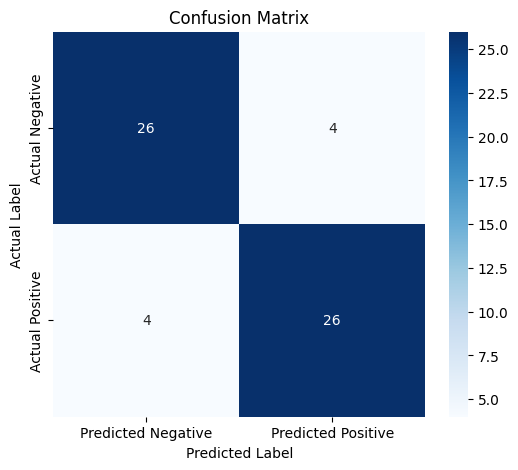

In [ ]:
# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

print("\nConfusion Matrix:")
display(pd.DataFrame(conf_matrix,
                     index=['Actual Negative', 'Actual Positive'],
                     columns=['Predicted Negative', 'Predicted Positive']))

# Visualize Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Negative', 'Predicted Positive'],
            yticklabels=['Actual Negative', 'Actual Positive'])
plt.title('Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

This code demonstrates how to set up, train, and evaluate a basic Naive Bayes classifier on a synthetic dataset. You can adapt this structure to your own datasets.

### Home Assignment

1. Use any standard dataset to do naive bayes classification (eg. mnist, iris)
2. Code your own classifer
3. Understand the evaluation metrices